# Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Set display options for better readability
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', 130)          # Increase horizontal display width
pd.set_option('display.max_colwidth', 100)   # Allow longer text in each column

# Load the dataset
data_path = "parkinsons_updrs.csv"
data = pd.read_csv(data_path)

# Display first few rows
print("First 5 records of the dataset:")
print(data.head())

# Display basic information about the dataset
print("\nDataset Information:")
print(data.info())

# Display basic statistics
print("\nDescriptive Statistics:")
print(data.describe().T)

# Check for missing values
print("\nMissing Values per Column:")
print(data.isnull().sum())

# Check the shape of the dataset
print(f"\nDataset Shape: {data.shape[0]} rows, {data.shape[1]} columns")

# Preview column names
print("\nColumn Names:")
print(list(data.columns))

# Identify target and features
target_vars = ['motor_UPDRS', 'total_UPDRS']
feature_cols = [col for col in data.columns if col not in ['motor_UPDRS', 'total_UPDRS']]

print("\nFeature Columns:")
print(feature_cols)
print("\nTarget Variables:")
print(target_vars)

First 5 records of the dataset:
   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  Jitter:DDP  \
0         1   72    0     5.6431       28.199       34.398    0.00662     0.000034     0.00401      0.00317     0.01204   
1         1   72    0    12.6660       28.447       34.894    0.00300     0.000017     0.00132      0.00150     0.00395   
2         1   72    0    19.6810       28.695       35.389    0.00481     0.000025     0.00205      0.00208     0.00616   
3         1   72    0    25.6470       28.905       35.810    0.00528     0.000027     0.00191      0.00264     0.00573   
4         1   72    0    33.6420       29.187       36.375    0.00335     0.000020     0.00093      0.00130     0.00278   

   Shimmer  Shimmer(dB)  Shimmer:APQ3  Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE      DFA      PPE  
0  0.02565        0.230       0.01438       0.01309        0.01662      0.04314  0.014290  21.640  0.4

# Data Preprocessing

In [2]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = data.drop(columns=['motor_UPDRS', 'total_UPDRS'])
y_motor = data['motor_UPDRS']         # target 1
y_total = data['total_UPDRS']         # target 2

# Display the shapes
print(f"Feature matrix shape: {X.shape}")
print(f"Motor UPDRS target shape: {y_motor.shape}")
print(f"Total UPDRS target shape: {y_total.shape}")

# 1. Handle missing values (none expected, but safety check)
if X.isnull().sum().any():
    print("Missing values detected. Filling with column means.")
    X = X.fillna(X.mean())
else:
    print("No missing values detected.")

# 2. Remove or encode non-numeric identifiers (e.g., subject#)
# 'subject#' is an ID column, not a predictive feature
X = X.drop(columns=['subject#'])

# 3. Feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled array back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nScaled feature sample:")
print(X_scaled.head())

# 4. Train-test split (80-20)
X_train, X_test, y_train_motor, y_test_motor = train_test_split(
    X_scaled, y_motor, test_size=0.2, random_state=42
)

X_train2, X_test2, y_train_total, y_test_total = train_test_split(
    X_scaled, y_total, test_size=0.2, random_state=42
)

# Display data split information
print("\nTraining and testing set shapes:")
print(f"Motor UPDRS: X_train={X_train.shape}, X_test={X_test.shape}")
print(f"Total UPDRS: X_train2={X_train2.shape}, X_test2={X_test2.shape}")

Feature matrix shape: (5875, 20)
Motor UPDRS target shape: (5875,)
Total UPDRS target shape: (5875,)
No missing values detected.

Scaled feature sample:
        age       sex  test_time  Jitter(%)  Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  Jitter:DDP   Shimmer  Shimmer(dB)  \
0  0.815695 -0.682509  -1.632090   0.082905    -0.284379    0.327453    -0.028637    0.328505 -0.324594    -0.351642   
1  0.815695 -0.682509  -1.500676  -0.560793    -0.756869   -0.533746    -0.476212   -0.534825 -0.534016    -0.573156   
2  0.815695 -0.682509  -1.369410  -0.238944    -0.540080   -0.300038    -0.320767   -0.298983 -0.669115    -0.564469   
3  0.815695 -0.682509  -1.257773  -0.155370    -0.484493   -0.344859    -0.170682   -0.344871 -0.423692     0.069668   
4  0.815695 -0.682509  -1.108169  -0.498557    -0.665151   -0.658604    -0.529814   -0.659682 -0.658276    -0.586186   

   Shimmer:APQ3  Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR       HNR      RPDE       DFA       PPE  
0     -0.209709 

# Feature Overview

Top 12 Acoustic Features most correlated with motor_UPDRS:
1. age
2. PPE
3. HNR
4. Shimmer:APQ11
5. RPDE
6. DFA
7. Shimmer(dB)
8. Shimmer
9. Shimmer:APQ5
10. Jitter(%)
11. Shimmer:APQ3
12. Shimmer:DDA


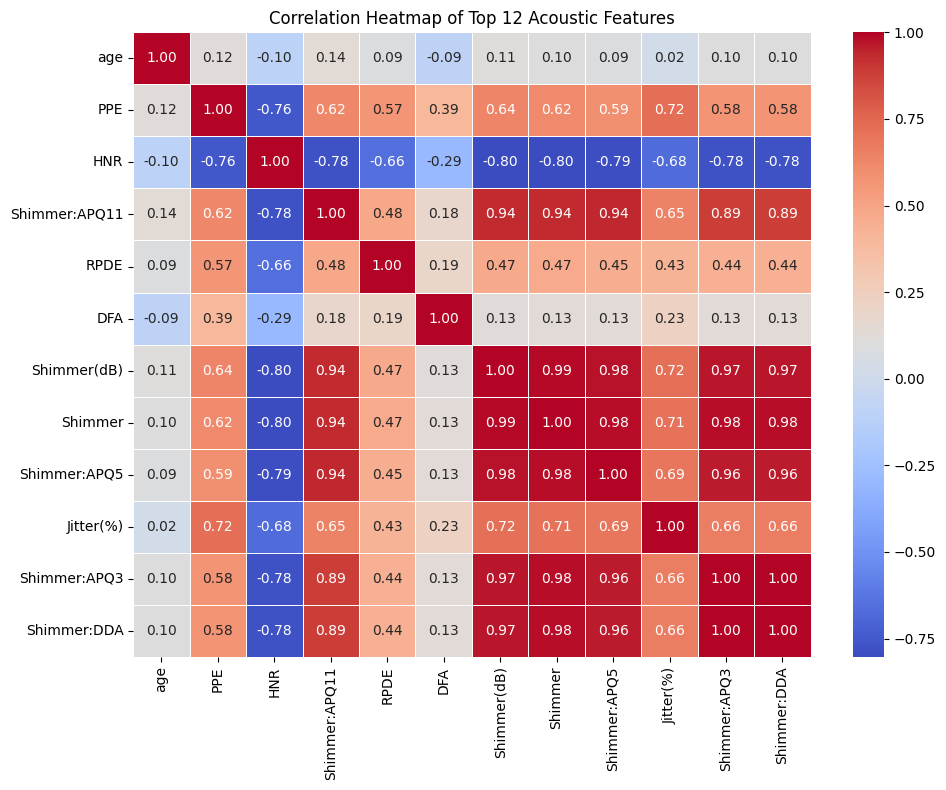

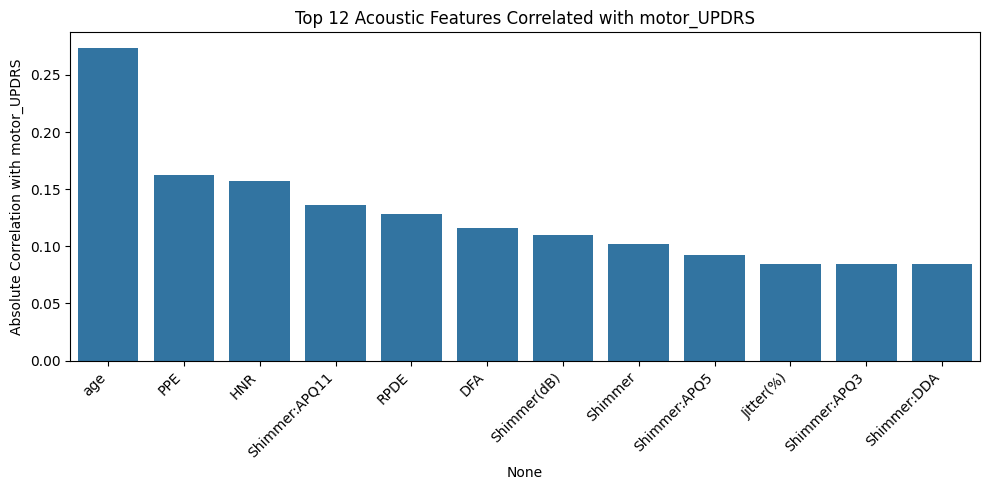

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Identify acoustic features (remove demographic/time variables)
acoustic_features = [col for col in X_scaled.columns if col not in ['age', 'sex', 'test_time']]

# Compute correlations with target variable (motor_UPDRS)
corr_with_motor = pd.concat([X_scaled, y_motor], axis=1).corr()['motor_UPDRS'].drop('motor_UPDRS').abs()
corr_with_motor = corr_with_motor.sort_values(ascending=False)

# Select top 8–12 features (here we use 12)
top_features = corr_with_motor.head(12).index.tolist()

# Display top features list
print("Top 12 Acoustic Features most correlated with motor_UPDRS:")
for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")

# Plot 1: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X_scaled[top_features].corr(), cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Top 12 Acoustic Features")
plt.tight_layout()
plt.show()

# Plot 2: Bar Plot – Feature Correlation Strength
plt.figure(figsize=(10, 5))
sns.barplot(x=corr_with_motor.head(12).index, y=corr_with_motor.head(12).values)
plt.title("Top 12 Acoustic Features Correlated with motor_UPDRS")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Absolute Correlation with motor_UPDRS")
plt.tight_layout()
plt.show()

# Modelling

## Random Forest


Random Forest Regression Evaluation:
RMSE: 1.3086
MAE:  0.6155
R²:   0.9732
Cross-Validation R² Mean: -0.9661 | Std: 0.6726


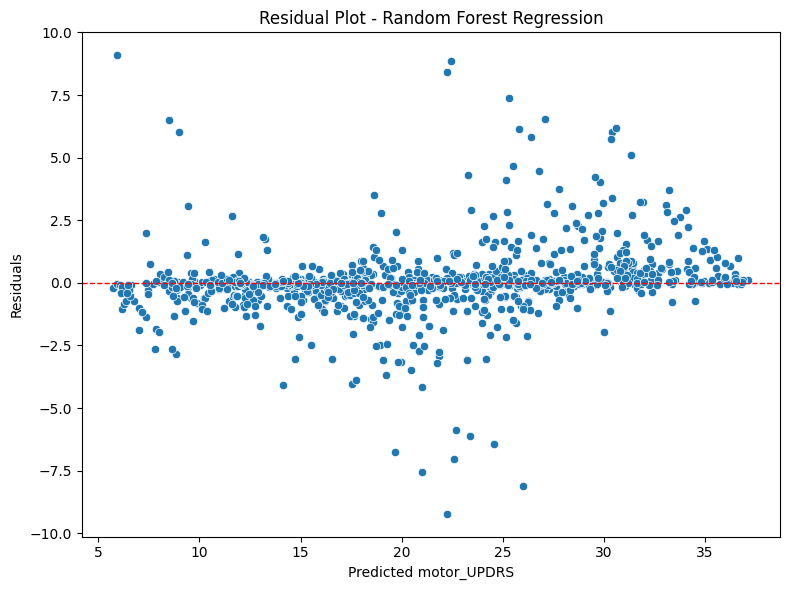


Top 10 Important Features:
         Feature  Importance
0            age    0.665060
17           DFA    0.076787
2      test_time    0.076139
1            sex    0.064523
4    Jitter(Abs)    0.026453
15           HNR    0.017242
18           PPE    0.012301
14           NHR    0.008799
16          RPDE    0.007287
11  Shimmer:APQ5    0.006793


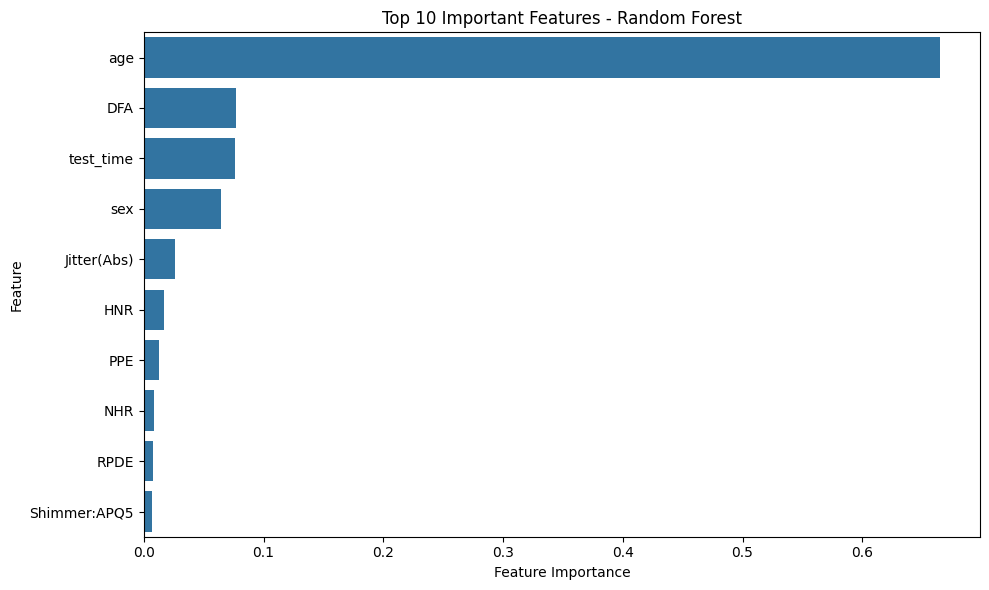

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define features and target variable
X = data.drop(columns=['motor_UPDRS', 'total_UPDRS', 'subject#'])
y = data['motor_UPDRS']

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate regression performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest Regression Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Cross-validation for robustness
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-Validation R² Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

# Residual plot for error analysis
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted motor_UPDRS")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regression")
plt.tight_layout()
plt.show()

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## XGBoost


XGBoost Regression Evaluation:
RMSE: 1.8506
MAE:  1.3006
R²:   0.9463
Cross-Validation R² Mean: -0.9050 | Std: 0.5675


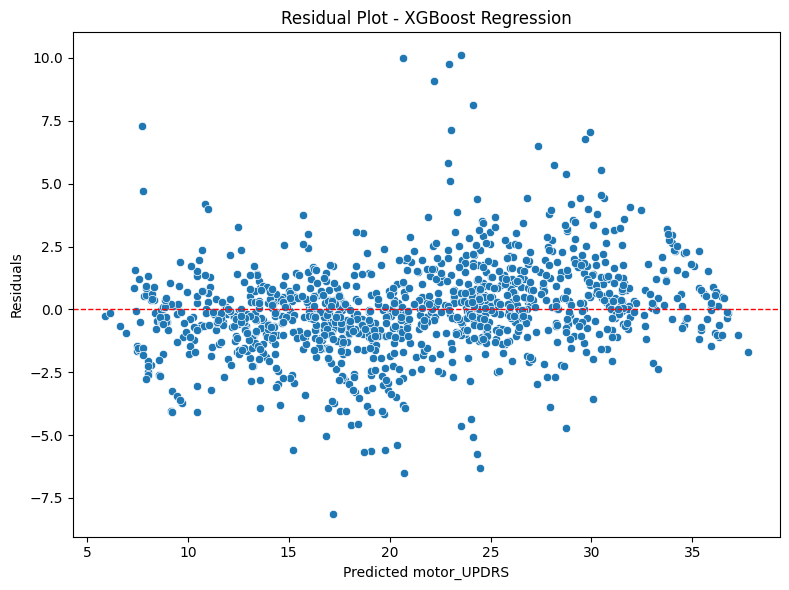


Top 10 Important Features:
         Feature  Importance
0            age    0.296291
1            sex    0.176455
17           DFA    0.083701
15           HNR    0.053756
4    Jitter(Abs)    0.051314
13   Shimmer:DDA    0.050996
11  Shimmer:APQ5    0.038650
10  Shimmer:APQ3    0.032130
16          RPDE    0.031172
2      test_time    0.029679


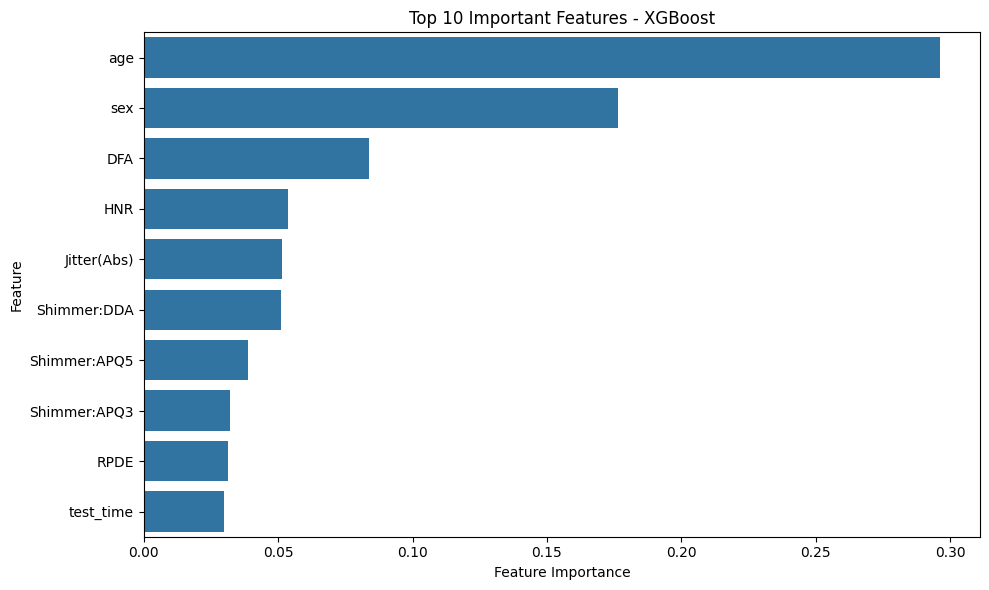

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Define features and target variable
X = data.drop(columns=['motor_UPDRS', 'total_UPDRS', 'subject#'])
y = data['motor_UPDRS']

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Initialize and train XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse'
)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate regression performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nXGBoost Regression Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Cross-validation for robustness
cv_scores = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-Validation R² Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

# Residual plot for error analysis
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted motor_UPDRS")
plt.ylabel("Residuals")
plt.title("Residual Plot - XGBoost Regression")
plt.tight_layout()
plt.show()

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Support Vector Regressor


Support Vector Regression Evaluation:
RMSE: 5.4923
MAE:  4.1525
R²:   0.5274
Cross-Validation R² Mean: -1.2661 | Std: 0.7765


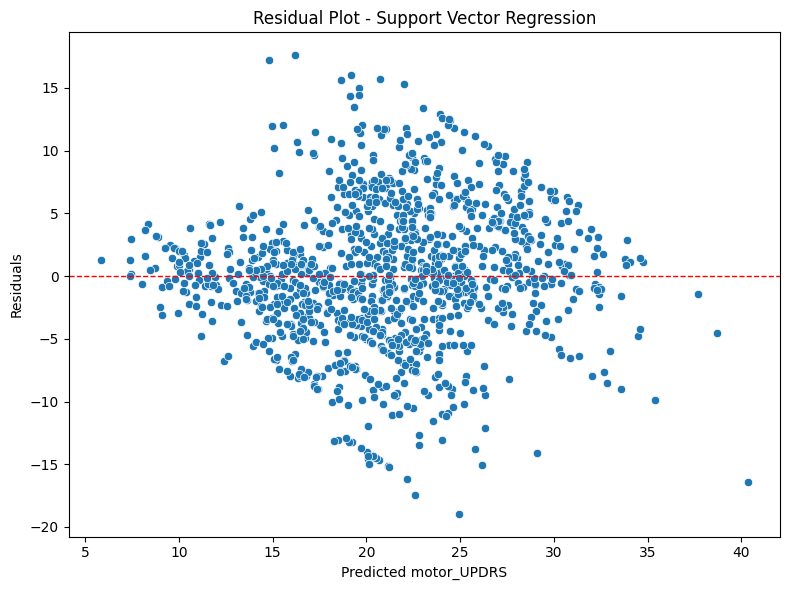


Top 10 Important Features (Permutation Importance):
          Feature  Importance
0             age    0.478364
1             sex    0.379777
17            DFA    0.286974
18            PPE    0.147871
4     Jitter(Abs)    0.139730
16           RPDE    0.127030
15            HNR    0.111304
12  Shimmer:APQ11    0.075574
2       test_time    0.066326
7      Jitter:DDP    0.057811


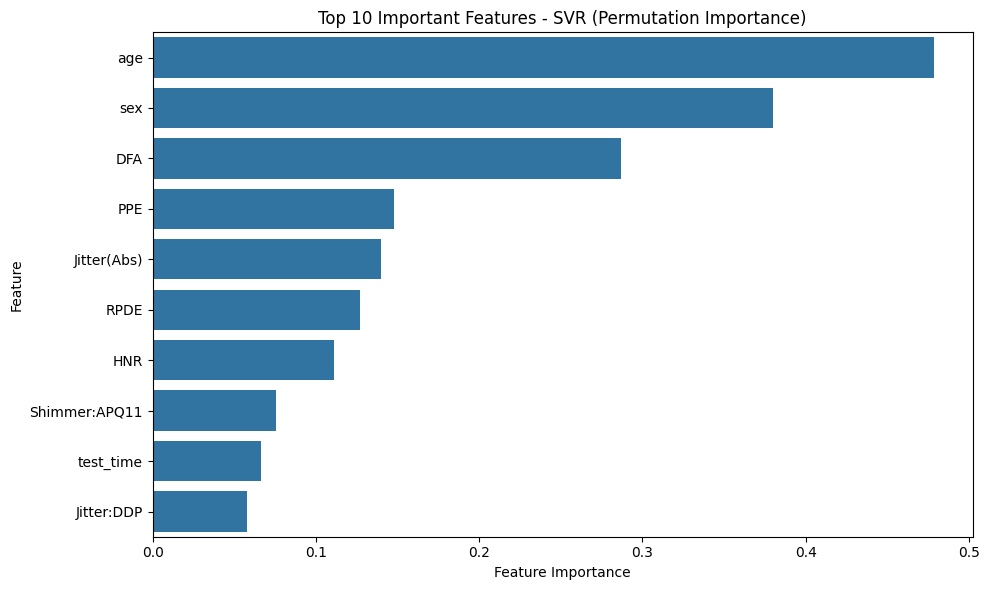

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Define features and target variable
X = data.drop(columns=['motor_UPDRS', 'total_UPDRS', 'subject#'])
y = data['motor_UPDRS']

# Scale features (essential for SVR)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Initialize and train Support Vector Regressor
svr_model = SVR(kernel='rbf', C=10, epsilon=0.2)
svr_model.fit(X_train, y_train)

# Make predictions
y_pred = svr_model.predict(X_test)

# Evaluate regression performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nSupport Vector Regression Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Cross-validation for robustness
cv_scores = cross_val_score(svr_model, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-Validation R² Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

# Residual plot for error analysis
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted motor_UPDRS")
plt.ylabel("Residuals")
plt.title("Residual Plot - Support Vector Regression")
plt.tight_layout()
plt.show()

# Permutation feature importance (since SVR has no built-in importance)
perm_importance = permutation_importance(svr_model, X_test, y_test, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features (Permutation Importance):")
print(importance_df.head(10))

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top 10 Important Features - SVR (Permutation Importance)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Model Comparison


Model Comparison Summary:
           Model      R²    RMSE     MAE  CV Mean R²  CV Std R²
0  Random Forest  0.9732  1.3086  0.6155     -0.9661     0.6726
1        XGBoost  0.9463  1.8506  1.3006     -0.9050     0.5675
2            SVR  0.5274  5.4923  4.1525     -1.2661     0.7765

Best model by R²: Random Forest
Best model by RMSE: Random Forest
Best model by MAE: Random Forest


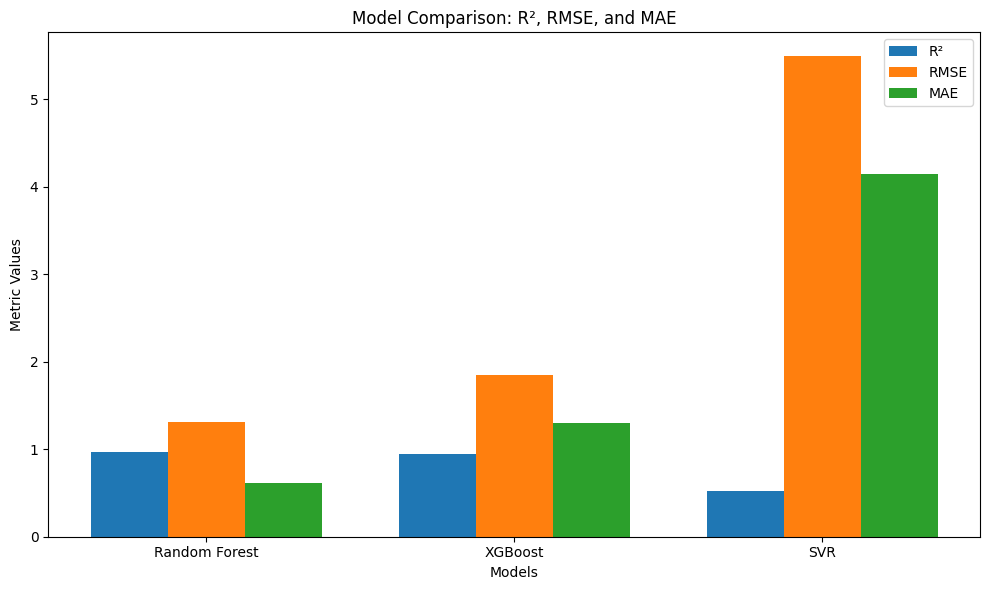

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define features and target variable
X = data.drop(columns=['motor_UPDRS', 'total_UPDRS', 'subject#'])
y = data['motor_UPDRS']

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Initialize models
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.8, random_state=42, eval_metric='rmse'
)
svr_model = SVR(kernel='rbf', C=10, epsilon=0.2)

# Dictionary of models
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'SVR': svr_model
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    cv_r2 = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    cv_mean = cv_r2.mean()
    cv_std = cv_r2.std()

    results.append({
        'Model': name,
        'R²': round(r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'CV Mean R²': round(cv_mean, 4),
        'CV Std R²': round(cv_std, 4)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\nModel Comparison Summary:")
print(results_df)

# Highlight best model in each metric
best_r2 = results_df.loc[results_df['R²'].idxmax(), 'Model']
best_rmse = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
best_mae = results_df.loc[results_df['MAE'].idxmin(), 'Model']

print(f"\nBest model by R²: {best_r2}")
print(f"Best model by RMSE: {best_rmse}")
print(f"Best model by MAE: {best_mae}")

# Comparison Plot
metrics = ['R²', 'RMSE', 'MAE']
models = results_df['Model']
values = [
    results_df['R²'],
    results_df['RMSE'],
    results_df['MAE']
]

# Set up plot
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, values[0], width, label='R²')
plt.bar(x, values[1], width, label='RMSE')
plt.bar(x + width, values[2], width, label='MAE')

plt.xlabel("Models")
plt.ylabel("Metric Values")
plt.title("Model Comparison: R², RMSE, and MAE")
plt.xticks(x, models)
plt.legend()
plt.tight_layout()
plt.show()